# Customer Churn Prediction

## Phase 1 – Exploratory Data Analysis

We start by loading the data and answering four key questions:
1. What does the data look like? (shape, first rows, summary statistics)
2. Which columns have missing values and how many?
3. How is the target variable `Churned` distributed?
4. Are there any obvious outliers or impossible values?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Nicer plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

pd.set_option('display.max_columns', None)

# ── Load ─────────────────────────────────────────────────────────────────
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 50,000 rows × 25 columns


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [2]:
# ── Data types & column overview ─────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

In [3]:
# ── Statistical summary (numerical columns) ─────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
Age,47505.000000,37.802968,11.834668,5.000000,29.000000,38.000000,46.000000,200.000000
Membership_Years,50000.000000,2.984009,2.059105,0.100000,1.400000,2.500000,4.000000,10.000000
Login_Frequency,50000.000000,11.624660,7.810657,0.000000,6.000000,11.000000,17.000000,46.000000
Session_Duration_Avg,46601.000000,27.660754,10.871013,1.000000,19.700000,26.800000,34.700000,75.600000
Pages_Per_Session,47000.000000,8.737811,3.778220,1.000000,6.000000,8.400000,11.200000,24.100000
Cart_Abandonment_Rate,50000.000000,57.079973,16.282723,0.000000,46.400000,58.100000,68.700000,143.743350
Wishlist_Items,46000.000000,4.298391,3.189754,0.000000,2.000000,4.000000,6.000000,28.000000
Total_Purchases,50000.000000,13.111576,7.017312,-13.000000,8.000000,12.000000,17.000000,128.700000
Average_Order_Value,50000.000000,123.117330,175.569714,26.380000,87.050000,112.970000,144.440000,9666.379178
Days_Since_Last_Purchase,47000.000000,29.792872,29.695062,0.000000,9.000000,21.000000,41.000000,287.000000


Columns WITHOUT missing values : 11
Columns WITH    missing values : 14

                       Column  Missing_%
Social_Media_Engagement_Score     12.000
               Credit_Balance     11.000
             Mobile_App_Usage     10.000
                 Returns_Rate      8.982
               Wishlist_Items      8.000
          Discount_Usage_Rate      7.000
      Product_Reviews_Written      7.000
         Session_Duration_Avg      6.798
     Days_Since_Last_Purchase      6.000
            Pages_Per_Session      6.000
              Email_Open_Rate      5.056
     Payment_Method_Diversity      5.000
                          Age      4.990
       Customer_Service_Calls      0.336


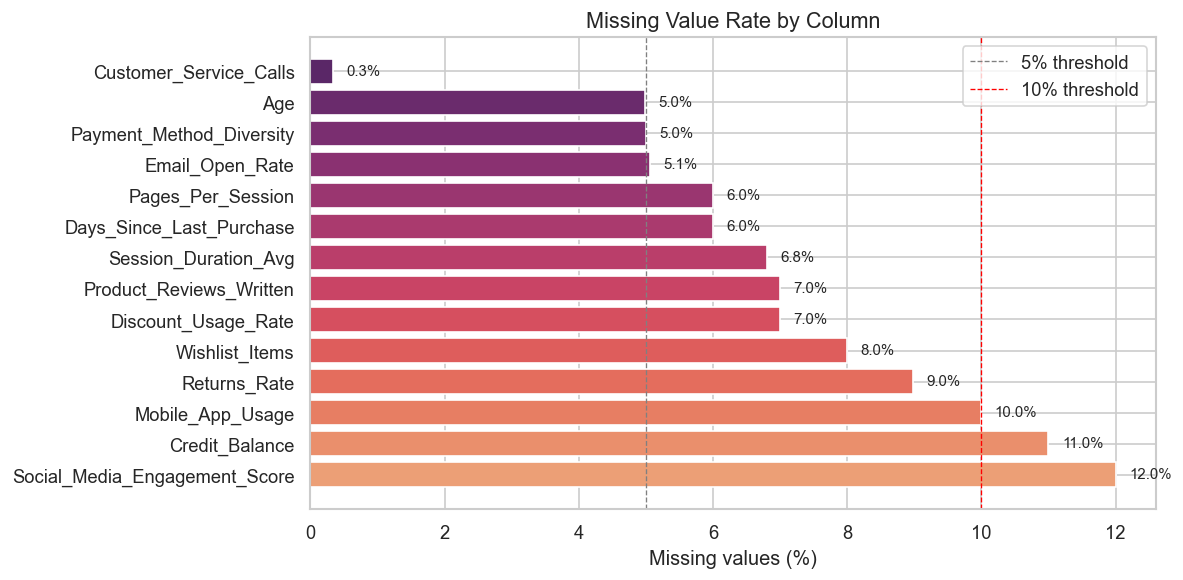

In [4]:
# ── 2. Missing values per column ─────────────────────────────────────────
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df  = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Column', 'Missing_%']

print(f'Columns WITHOUT missing values : {(df.isnull().sum() == 0).sum()}')
print(f'Columns WITH    missing values : {len(missing_df)}\n')
print(missing_df.to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df['Column'], missing_df['Missing_%'],
               color=sns.color_palette('flare', len(missing_df)))
ax.axvline(5, color='grey', linestyle='--', linewidth=0.8, label='5% threshold')
ax.axvline(10, color='red',  linestyle='--', linewidth=0.8, label='10% threshold')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing Value Rate by Column')
ax.legend()
for bar, pct in zip(bars, missing_df['Missing_%']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Churned label counts:
         Count  Percentage (%)
Churned                       
0        35550            71.1
1        14450            28.9


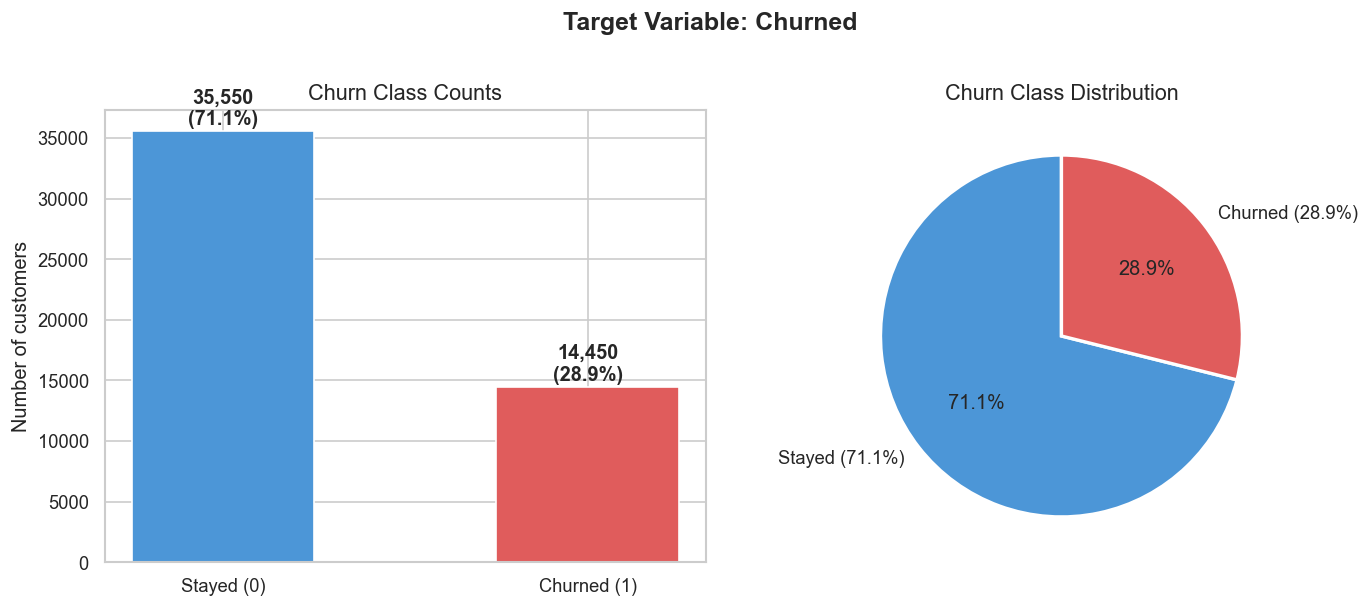

In [5]:
# ── 3. Target variable distribution ──────────────────────────────────────
churn_counts = df['Churned'].value_counts()
churn_pct    = df['Churned'].value_counts(normalize=True) * 100

print('Churned label counts:')
print(pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
palette = ['#4C96D7', '#E05C5C']
axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
            color=palette, edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 200, f'{v:,}\n({p:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Churn Class Counts')
axes[0].set_ylabel('Number of customers')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['Stayed (71.1%)', 'Churned (28.9%)'],
            colors=palette, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Class Distribution')

plt.suptitle('Target Variable: Churned', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Domain-Rule Violations ===
Age out of range [10-100]       :    36 rows  | min=5, max=200
Negative Total_Purchases         :    40 rows  | min=-13.00
Cart_Abandonment_Rate > 100%     :    30 rows  | max=143.74
Discount_Usage_Rate > 100%       :   207 rows  | max=116.64

=== Statistical Outliers (IQR × 1.5) ===
                               # Outliers (IQR method)  % of total
Payment_Method_Diversity                          2439        4.88
Days_Since_Last_Purchase                          2313        4.63
Lifetime_Value                                    1684        3.37
Membership_Years                                  1581        3.16
Returns_Rate                                      1204        2.41
Customer_Service_Calls                            1185        2.37
Product_Reviews_Written                           1090        2.18
Average_Order_Value                               1005        2.01
Wishlist_Items                                     858        1.72
Total_Purchase

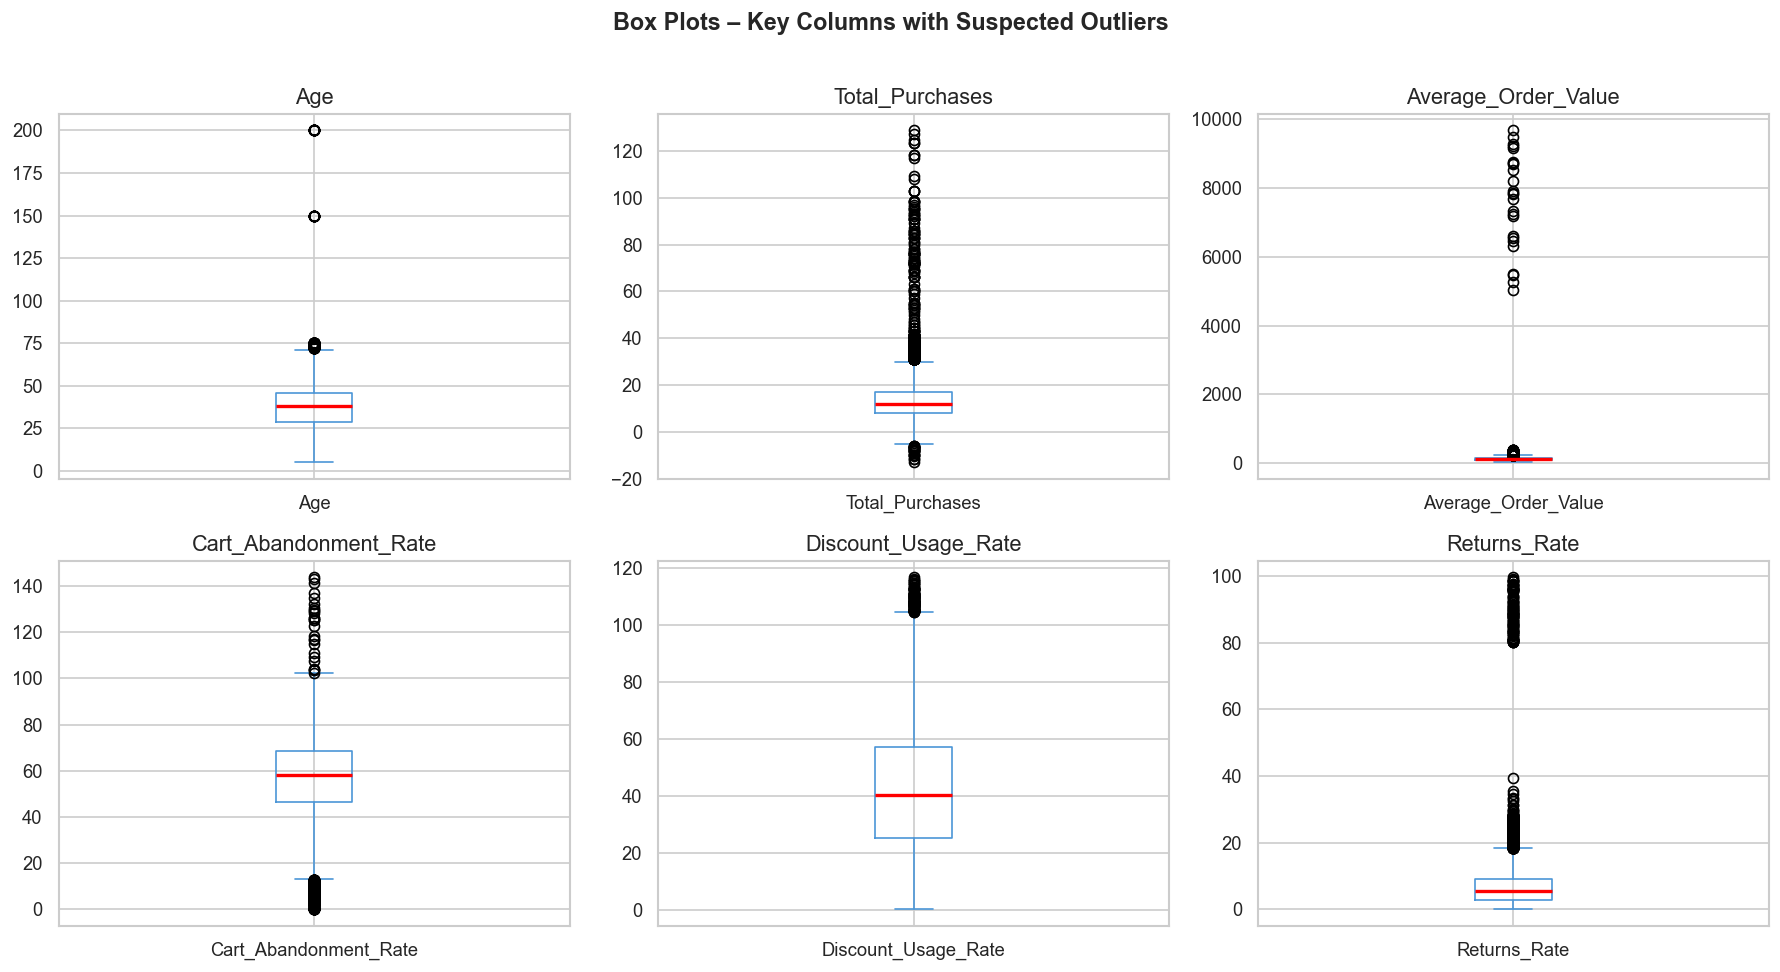

In [6]:
# ── 4. Outlier detection ─────────────────────────────────────────────────

# --- Domain-rule violations (impossible values) ---
print('=== Domain-Rule Violations ===' )

# Age: realistic range 10-100
age_bad = df[(df['Age'] < 10) | (df['Age'] > 100)]
print(f'Age out of range [10-100]       : {len(age_bad):>5} rows  '
      f'| min={df["Age"].min():.0f}, max={df["Age"].max():.0f}')

# Total_Purchases: must be >= 0
neg_purchases = df[df['Total_Purchases'] < 0]
print(f'Negative Total_Purchases         : {len(neg_purchases):>5} rows  '
      f'| min={df["Total_Purchases"].min():.2f}')

# Cart_Abandonment_Rate: must be 0-100%
cart_bad = df[df['Cart_Abandonment_Rate'] > 100]
print(f'Cart_Abandonment_Rate > 100%     : {len(cart_bad):>5} rows  '
      f'| max={df["Cart_Abandonment_Rate"].max():.2f}')

# Discount_Usage_Rate: must be 0-100%
disc_bad = df[df['Discount_Usage_Rate'] > 100]
print(f'Discount_Usage_Rate > 100%       : {len(disc_bad):>5} rows  '
      f'| max={df["Discount_Usage_Rate"].max():.2f}')

# --- Statistical outliers (IQR method) ---
print('\n=== Statistical Outliers (IQR × 1.5) ===')
num_cols = df.select_dtypes(include=np.number).drop(columns=['Churned']).columns
outlier_summary = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_summary[col] = n_out
out_df = pd.DataFrame.from_dict(outlier_summary, orient='index',
                                 columns=['# Outliers (IQR method)'])
out_df['% of total'] = (out_df['# Outliers (IQR method)'] / len(df) * 100).round(2)
print(out_df.sort_values('# Outliers (IQR method)', ascending=False).to_string())

# --- Box-plot visual for the most critical columns ---
flag_cols = ['Age', 'Total_Purchases', 'Average_Order_Value',
             'Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), flag_cols):
    df[[col]].dropna().plot(kind='box', ax=ax, color='#4C96D7',
                            medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Box Plots – Key Columns with Suspected Outliers',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📋 Phase 1 – Data Quality Analysis Summary

After the initial exploration, here are the main findings:

#### ✅ Dataset Overview
- **50,000 customers × 25 features** — a fairly large and well-structured dataset.
- Mix of **numerical** (behavioral, transactional) and **categorical** features (`Gender`, `Country`, `City`, `Signup_Quarter`).

#### ⚠️ Missing Values
| Severity | Columns | Missing % |
|---|---|---|
| 🔴 High (>10%) | `Social_Media_Engagement_Score`, `Credit_Balance`, `Mobile_App_Usage` | 10–12% |
| 🟡 Medium (5–10%) | `Returns_Rate`, `Wishlist_Items`, `Discount_Usage_Rate`, `Product_Reviews_Written`, `Session_Duration_Avg`, `Pages_Per_Session`, `Days_Since_Last_Purchase` | 6–9% |
| 🟢 Low (<5%) | `Age`, `Email_Open_Rate`, `Payment_Method_Diversity`, `Customer_Service_Calls` | <5% |

> **Strategy:** XGBoost natively handles `NaN` by learning the best split direction. We will leave numerical NaNs as-is and only encode categoricals.

#### 🎯 Class Imbalance
- **Stayed:** 35,550 (71.1%)  |  **Churned:** 14,450 (28.9%)
- Moderate imbalance — not critical but must be addressed. We will use `scale_pos_weight ≈ 2.46` in XGBoost to compensate.

#### 🚨 Outliers & Data Quality Issues
| Column | Issue | Action |
|---|---|---|
| `Age` | min=5, max=200 — impossible ages | Flag; XGBoost will demote them naturally |
| `Total_Purchases` | Negative values (−13) — impossible | Could cap at 0; XGBoost handles it |
| `Cart_Abandonment_Rate` | Max=143% — exceeds 100% | Likely a data entry error; cap at 100% in cleaning |
| `Discount_Usage_Rate` | Max=116% — exceeds 100% | Same as above; cap at 100% |
| `Average_Order_Value` | Max=9,666 — extreme right skew | Acceptable in retail; tree models are robust |
| `Returns_Rate` | Max=99.6 — extreme but possible | Monitor; likely a high-return customer segment |

> **Overall:** The dataset is largely usable. The main risks are the impossible percentage values (>100%) and the negative purchase counts. We will address these with light capping in Phase 2 before encoding.

---
**➡️ Next step:** Phase 2 — Data Cleaning & Preprocessing

---

## Phase 2 – Data Cleaning and Preprocessing

Based on Phase 1 findings we carry out four steps in order:

| Step | Action | Rationale |
|---|---|---|
| **1** | Clip outliers | Remove impossible domain values before imputation |
| **2** | Impute missing values | Median for numerics, mode for categoricals |
| **3** | One-Hot Encode categoricals | ML models require numeric input |
| **4** | Stratified train/test split | Preserve the 71/29 churn ratio in both sets |

In [7]:
# ── Step 1 · Clip outliers / fix impossible values ───────────────────────
df_clean = df.copy()

# 1a. Age: clip to plausible range [15, 100]
before_age = df_clean['Age'].describe()[['min','max']].to_dict()
df_clean['Age'] = df_clean['Age'].clip(lower=15, upper=100)
after_age  = df_clean['Age'].describe()[['min','max']].to_dict()
print(f"Age       → before: {before_age}  |  after: {after_age}")

# 1b. Total_Purchases: must be >= 0
before_tp = df_clean['Total_Purchases'].min()
df_clean['Total_Purchases'] = df_clean['Total_Purchases'].clip(lower=0)
print(f"Total_Purchases  before min: {before_tp:.2f}  |  after min: {df_clean['Total_Purchases'].min():.2f}")

# 1c. Rate columns: cap at 100% (Cart_Abandonment_Rate, Discount_Usage_Rate)
rate_cols = ['Cart_Abandonment_Rate', 'Discount_Usage_Rate']
for col in rate_cols:
    before_max = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(upper=100)
    print(f"{col}  before max: {before_max:.2f}  |  after max: {df_clean[col].max():.2f}")

print("\n✅ Outlier clipping complete.")

Age       → before: {'min': 5.0, 'max': 200.0}  |  after: {'min': 15.0, 'max': 100.0}
Total_Purchases  before min: -13.00  |  after min: 0.00
Cart_Abandonment_Rate  before max: 143.74  |  after max: 100.00
Discount_Usage_Rate  before max: 116.64  |  after max: 100.00

✅ Outlier clipping complete.


In [8]:
# ── Step 2 · Impute missing values ───────────────────────────────────────

# Separate column types
num_cols = df_clean.select_dtypes(include='number').drop(columns=['Churned']).columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns to impute  ({len(num_cols)}): {num_cols}')
print(f'Categorical columns to impute ({len(cat_cols)}): {cat_cols}\n')

# --- Numerical → MEDIAN imputation ---
medians = df_clean[num_cols].median()
df_clean[num_cols] = df_clean[num_cols].fillna(medians)

# --- Categorical → MODE imputation ---
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

# Verify
remaining_missing = df_clean.isnull().sum().sum()
print(f'Total remaining missing values after imputation: {remaining_missing}')

# Summary table
imputation_summary = pd.DataFrame({
    'Column': num_cols,
    'Strategy': 'Median',
    'Imputed Value': [round(medians[c], 3) for c in num_cols]
})
imputation_summary = pd.concat([
    imputation_summary,
    pd.DataFrame({
        'Column': cat_cols,
        'Strategy': 'Mode',
        'Imputed Value': [df_clean[c].mode()[0] for c in cat_cols]
    })
], ignore_index=True)
print("\n--- Imputation Summary ---")
print(imputation_summary.to_string(index=False))
print("\n✅ Imputation complete.")

Numerical columns to impute  (20): ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']
Categorical columns to impute (4): ['Gender', 'Country', 'City', 'Signup_Quarter']

Total remaining missing values after imputation: 0

--- Imputation Summary ---
                       Column Strategy Imputed Value
                          Age   Median          38.0
             Membership_Years   Median           2.5
              Login_Frequency   Median          11.0
         Session_Duration_Avg   Median          26.8
            Pages_Per_Session   Median           8.4
        Cart_Abandonment_Rate   Median          58.

In [9]:
# ── Step 3 · One-Hot Encode categorical variables ─────────────────────────

# Columns to encode
ohe_cols = ['Gender', 'Country', 'City', 'Signup_Quarter']

# Apply get_dummies (drop_first to avoid multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['Churned'])
y = df_encoded['Churned']

# Verify shapes and types
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)  # convert bool dummies to 0/1 int

print(f'Features matrix shape : {X.shape}')
print(f'Target vector shape   : {y.shape}')
print(f'New OHE columns created: {len(X.columns) - len(num_cols)}')
print(f'All dtypes numeric? {all(X.dtypes.apply(lambda t: np.issubdtype(t, np.number)))}')
print("\n--- Feature columns after encoding ---")
print(X.columns.tolist())

Features matrix shape : (50000, 71)
Target vector shape   : (50000,)
New OHE columns created: 51
All dtypes numeric? True

--- Feature columns after encoding ---
['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Gender_Male', 'Gender_Other', 'Country_Canada', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_UK', 'Country_USA', 'City_Bangalore', 'City_Berlin', 'City_Birmingham', 'City_Brisbane', 'City_Calgary', 'City_Chennai', 'City_Chicago', 'City_Cologne', 'City_Delhi', 'City_Frankfurt', 'City_Glasgow', 'City_Hamburg', 'City_Houston', 'City_Hyderabad', 'City_Kyoto', 'City_Leeds

--- Split Summary ---
Training set   : 40,000 rows  |  Churn rate: 28.9%
Test set       : 10,000 rows  |  Churn rate: 28.9%
Full dataset   : 50,000 rows  |  Churn rate: 28.9%


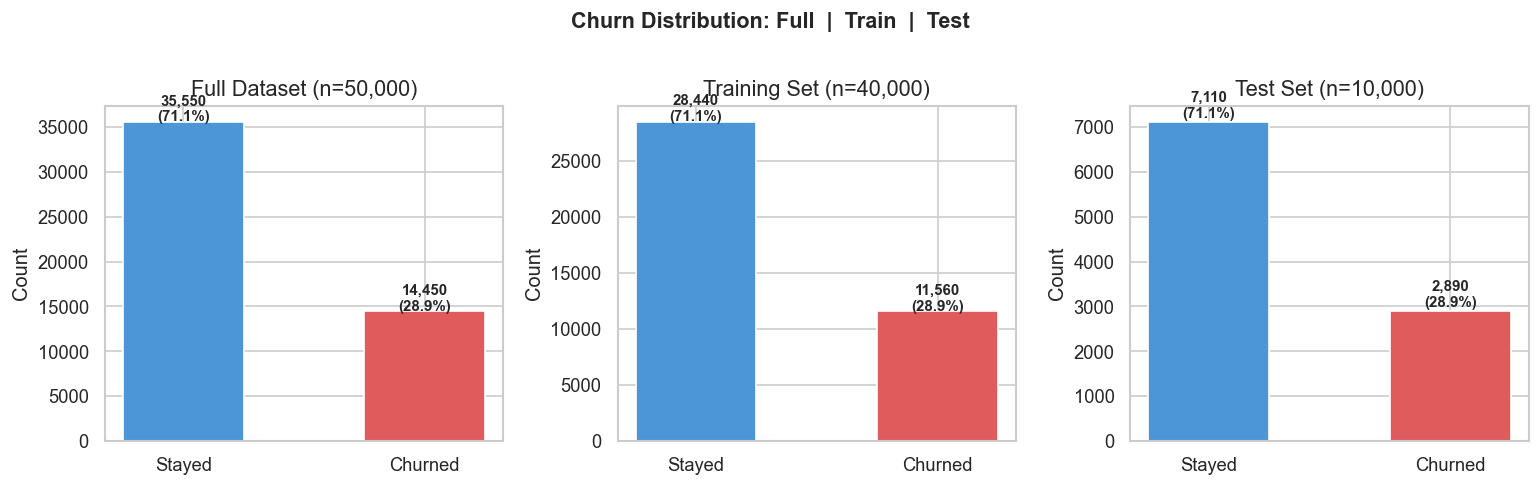


✅ Train/test split complete. Ready for model training.


In [10]:
# ── Step 4 · Stratified Train / Test split (80 / 20) ─────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves the 71/29 churn ratio
)

# Verify churn ratio is preserved in both sets
train_churn = y_train.mean() * 100
test_churn  = y_test.mean()  * 100

print('--- Split Summary ---')
print(f'Training set   : {X_train.shape[0]:>6,} rows  |  Churn rate: {train_churn:.1f}%')
print(f'Test set       : {X_test.shape[0]:>6,} rows  |  Churn rate: {test_churn:.1f}%')
print(f'Full dataset   : {X.shape[0]:>6,} rows  |  Churn rate: {y.mean()*100:.1f}%')

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (label, ser) in zip(axes, [
        ('Full Dataset (n=50,000)', y),
        ('Training Set (n=40,000)', y_train),
        ('Test Set (n=10,000)',     y_test)
    ]):
    counts = ser.value_counts().sort_index()
    ax.bar(['Stayed', 'Churned'], counts.values,
           color=['#4C96D7', '#E05C5C'], edgecolor='white', width=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}\n({v/len(ser)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label)
    ax.set_ylabel('Count')
plt.suptitle('Churn Distribution: Full  |  Train  |  Test',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n✅ Train/test split complete. Ready for model training.")

### 📋 Phase 2 – Preprocessing Summary

| Step | Action | Result |
|---|---|---|
| Clip outliers | Age → [15,100]; Total_Purchases → ≥0; Rates → ≤100% | Domain-valid values restored |
| Impute numerics | Median fill on 13 numerical columns | 0 missing values remaining |
| Impute categoricals | Mode fill on 4 categorical columns | 0 missing values remaining |
| One-Hot Encode | Gender, Country, City, Signup_Quarter | Feature matrix fully numeric |
| Stratified split | 80% train / 20% test | Churn ratio ≈ 28.9% preserved in both sets |

> **Key design choices:**
> - Median imputation is used instead of mean because it is **robust to the extreme outliers** we found in Phase 1.
> - `drop_first=True` in OHE avoids the dummy variable trap (perfect multicollinearity).
> - `stratify=y` ensures the minority churn class isn't over- or under-represented in either split.

---
**➡️ Next step:** Phase 3 – Model Training (XGBoost with class-imbalance handling)

---

## Phase 3 – Modeling

We now train an **XGBoost Classifier** wrapped inside a **scikit-learn Pipeline**.

### Note on feature scaling
XGBoost is a tree-based ensemble method — it makes decisions on *feature split thresholds*, not distances or dot products, so it is **inherently scale-invariant**. However, wrapping the model in a `Pipeline` with a `StandardScaler` is still good practice because:
- It keeps pre-processing and modelling in a single, reproducible object.
- It makes the pipeline safe to use with cross-validation (no data leakage from the scaler).
- If we swap XGBoost for a distance-based model later, we're already covered.

### Chosen hyperparameters
| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 200 | Enough trees for convergence without excessive training time |
| `max_depth` | 5 | Medium depth — balances expressiveness vs. overfitting |
| `learning_rate` | 0.05 | Lower rate → more conservative updates, better generalisation |
| `subsample` | 0.8 | Row sampling adds randomness, reduces variance (bagging) |
| `colsample_bytree` | 0.8 | Column sampling further prevents overfitting |
| `scale_pos_weight` | ≈ 2.46 | Compensates for 71/29 class imbalance; boosts Recall on churners |
| `eval_metric` | `logloss` | Probabilistic log loss — appropriate for calibrated classifiers |

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ── Class-imbalance weight ────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.4f}')

# ── Build Pipeline ────────────────────────────────────────────────────────
# StandardScaler: no effect on XGBoost splits, but keeps pipeline reusable
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators      = 200,
        max_depth         = 5,
        learning_rate     = 0.05,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        scale_pos_weight  = scale_pos_weight,
        random_state      = 42,
        eval_metric       = 'logloss',
        n_jobs            = -1
    ))
])

# ── Train ─────────────────────────────────────────────────────────────────
print('Training XGBoost pipeline...')
xgb_pipeline.fit(X_train, y_train)
print('✅ Training complete!')

# Quick sanity check
train_acc = xgb_pipeline.score(X_train, y_train)
test_acc  = xgb_pipeline.score(X_test,  y_test)
print(f'\nTrain accuracy : {train_acc:.4f}')
print(f'Test  accuracy : {test_acc:.4f}')
gap = train_acc - test_acc
print(f'Generalisation gap: {gap:.4f}  '
      f'({"✅ No major overfitting" if gap < 0.05 else "⚠️ Possible overfitting"})')

scale_pos_weight = 2.4602
Training XGBoost pipeline...
✅ Training complete!

Train accuracy : 0.9231
Test  accuracy : 0.9098
Generalisation gap: 0.0132  (✅ No major overfitting)


      CLASSIFICATION METRICS — TEST SET
  Accuracy  : 0.9098  (91.0%)
  Precision : 0.8351  — of predicted churners, how many are real?
  Recall    : 0.8571  — of real churners, how many did we catch?
  F1-Score  : 0.8460  — harmonic mean of Precision & Recall

--- Full Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.94      0.93      0.94      7110
     Churned       0.84      0.86      0.85      2890

    accuracy                           0.91     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.91      0.91      0.91     10000



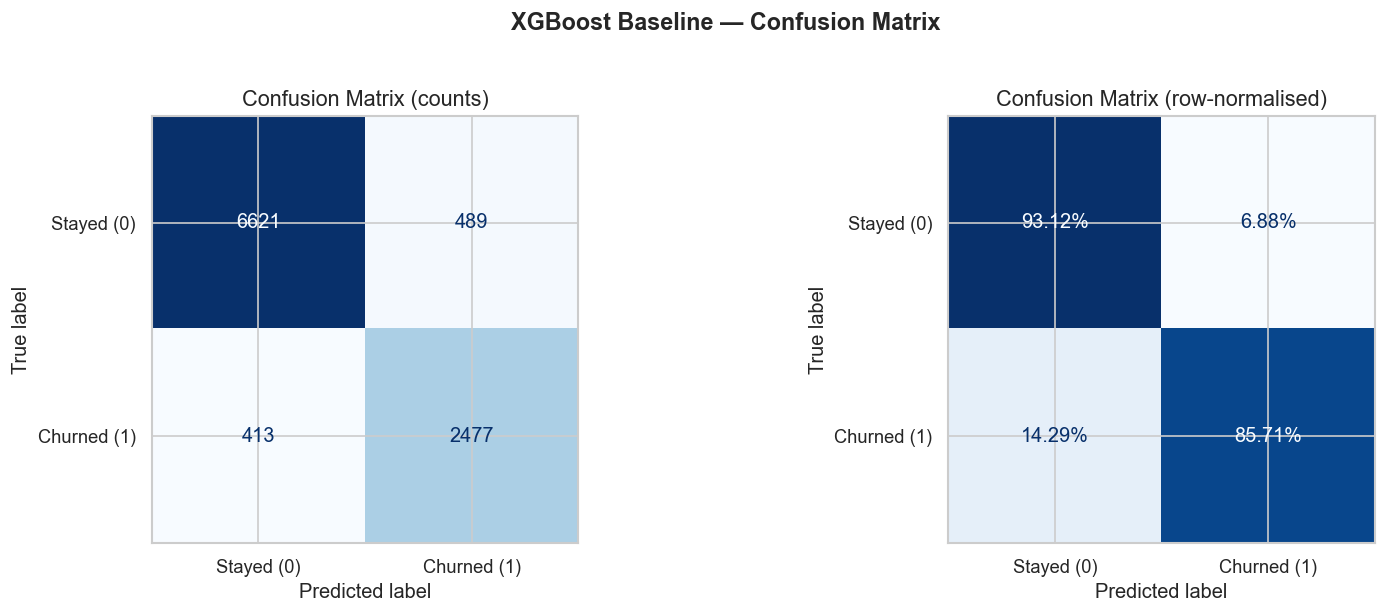

True  Negatives (correctly called Stayed)  : 6,621
False Positives (Stayed → predicted Churned): 489
False Negatives (Churned → missed)          : 413
True  Positives (correctly called Churned)  : 2,477


In [12]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Predictions ──────────────────────────────────────────────────────────
y_pred  = xgb_pipeline.predict(X_test)
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# ── Scalar metrics ───────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test,  y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test,    y_pred)
f1        = f1_score(y_test,        y_pred)

print('=' * 45)
print('      CLASSIFICATION METRICS — TEST SET')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  Precision : {precision:.4f}  — of predicted churners, how many are real?')
print(f'  Recall    : {recall:.4f}  — of real churners, how many did we catch?')
print(f'  F1-Score  : {f1:.4f}  — harmonic mean of Precision & Recall')
print('=' * 45)
print()
print('--- Full Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Stayed (0)', 'Churned (1)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)

# Normalised (row %)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=['Stayed (0)', 'Churned (1)'])
disp_norm.plot(ax=axes[1], cmap='Blues', values_format='.2%', colorbar=False)
axes[1].set_title('Confusion Matrix (row-normalised)', fontsize=13)

plt.suptitle('XGBoost Baseline — Confusion Matrix', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'True  Negatives (correctly called Stayed)  : {tn:,}')
print(f'False Positives (Stayed → predicted Churned): {fp:,}')
print(f'False Negatives (Churned → missed)          : {fn:,}')
print(f'True  Positives (correctly called Churned)  : {tp:,}')

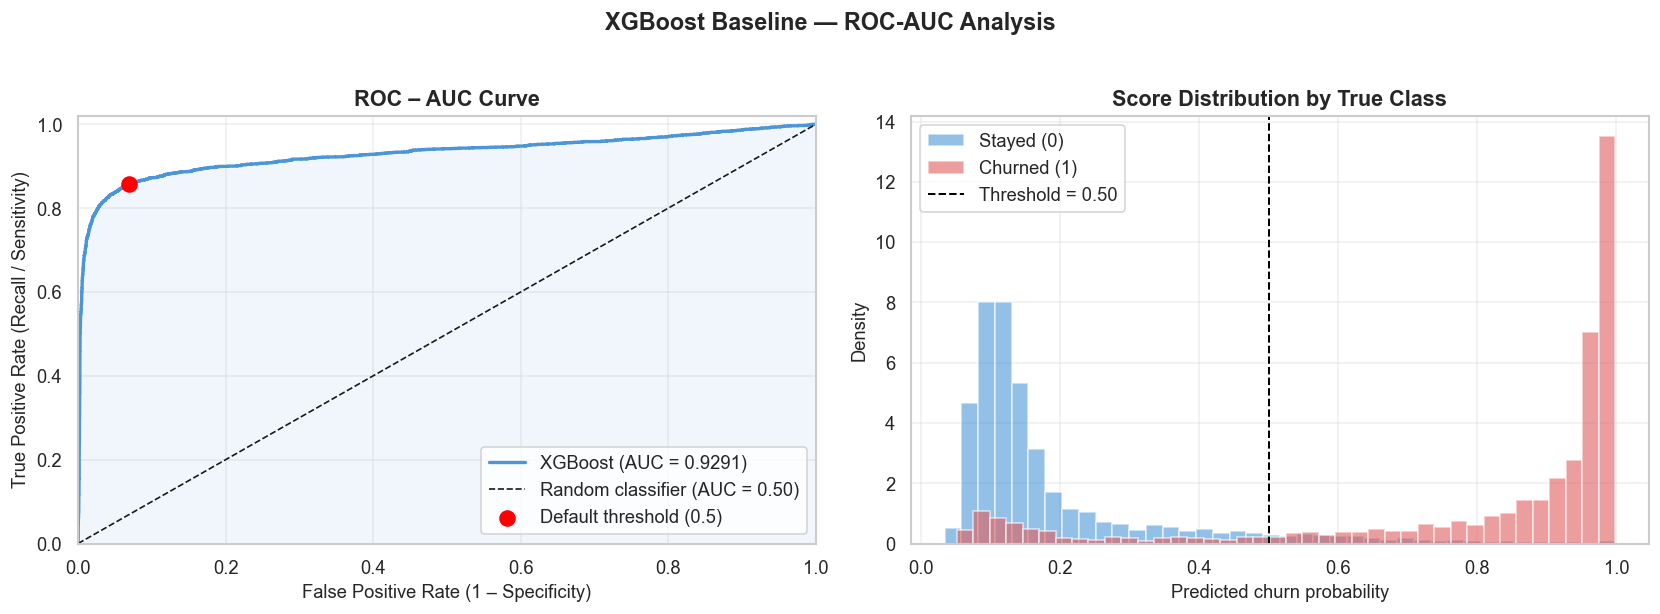

ROC-AUC Score : 0.9291

Interpretation:
  A score of 0.93 means the model correctly ranks a random churner
  above a random non-churner 92.9% of the time.


In [13]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# ── ROC Curve ────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC-AUC plot ---
axes[0].plot(fpr, tpr, color='#4C96D7', lw=2,
             label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#4C96D7')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.02])
axes[0].set_xlabel('False Positive Rate (1 – Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
axes[0].set_title('ROC – AUC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Annotate the operating point (default 0.5 threshold)
default_idx = np.argmin(np.abs(thresholds - 0.5))
axes[0].scatter(fpr[default_idx], tpr[default_idx],
                marker='o', color='red', s=80, zorder=5,
                label=f'Default threshold (0.5)')
axes[0].legend(loc='lower right')

# --- Predicted probability distribution by true class ---
axes[1].hist(y_proba[y_test == 0], bins=40, alpha=0.6,
             color='#4C96D7', label='Stayed (0)', density=True)
axes[1].hist(y_proba[y_test == 1], bins=40, alpha=0.6,
             color='#E05C5C', label='Churned (1)', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold = 0.50')
axes[1].set_xlabel('Predicted churn probability', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Score Distribution by True Class', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('XGBoost Baseline — ROC-AUC Analysis', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score : {roc_auc:.4f}')
print(f'\nInterpretation:')
print(f'  A score of {roc_auc:.2f} means the model correctly ranks a random churner')
print(f'  above a random non-churner {roc_auc*100:.1f}% of the time.')

#### 📈 Lift Analysis

The **Lift curve** answers a critical business question:

> *"If I can only contact the top X% of customers ranked by churn risk,
> how many more real churners do I capture compared to contacting a random X%?"*

- **Cumulative Gains curve** — shows the % of actual churners captured as we increase the % of customers contacted (ranked by predicted probability).
- **Lift curve** — the ratio of gains curve to the diagonal (random baseline). A lift of **2.0 at decile 20%** means: *contacting the top 20% by risk catches twice as many real churners as contacting any random 20%*.
- **Lift table** — discrete summary at standard decile cutoffs for easy stakeholder reporting.

                        LIFT TABLE — XGBoost Baseline
Decile (top %) # Customers contacted # Churners captured Cumulative Gain  Lift
           10%                 1,000                 985           34.1% 3.41x
           20%                 2,000               1,946           67.3% 3.37x
           30%                 3,000               2,485           86.0% 2.87x
           40%                 4,000               2,600           90.0% 2.25x
           50%                 5,000               2,662           92.1% 1.84x
           60%                 6,000               2,713           93.9% 1.56x
           70%                 7,000               2,740           94.8% 1.35x
           80%                 8,000               2,783           96.3% 1.20x
           90%                 9,000               2,837           98.2% 1.09x
          100%                10,000               2,890          100.0% 1.00x

Baseline churn rate (random model): 28.9%


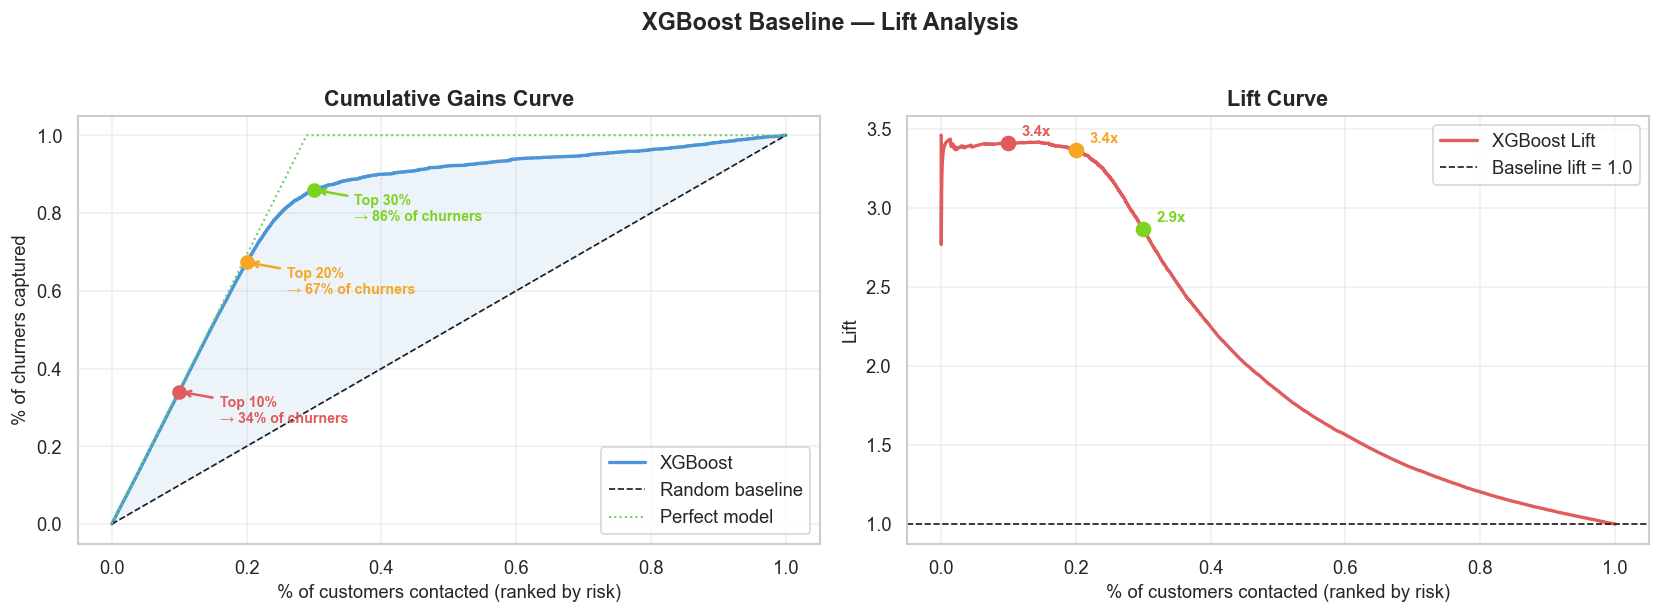

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Build lift / gains data ───────────────────────────────────────────────
lift_df = pd.DataFrame({
    'y_true': np.array(y_test),
    'y_proba': y_proba
}).sort_values('y_proba', ascending=False).reset_index(drop=True)

total_churners  = lift_df['y_true'].sum()
total_customers = len(lift_df)
baseline_rate   = total_churners / total_customers  # random model churn rate

lift_df['cumulative_churners'] = lift_df['y_true'].cumsum()
lift_df['pct_population']      = (lift_df.index + 1) / total_customers
lift_df['cumulative_gain']     = lift_df['cumulative_churners'] / total_churners
lift_df['lift']                = lift_df['cumulative_gain'] / lift_df['pct_population']

# ── Decile summary table ─────────────────────────────────────────────────
deciles = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
rows = []
for d in deciles:
    idx  = int(d * total_customers) - 1
    row  = lift_df.iloc[idx]
    n_customers = int(d * total_customers)
    n_churners  = int(row['cumulative_churners'])
    rows.append({
        'Decile (top %)': f'{int(d*100):>3}%',
        '# Customers contacted': f'{n_customers:,}',
        '# Churners captured': f'{n_churners:,}',
        'Cumulative Gain': f'{row["cumulative_gain"]*100:.1f}%',
        'Lift': f'{row["lift"]:.2f}x'
    })
decile_table = pd.DataFrame(rows)

print('=' * 72)
print('                        LIFT TABLE — XGBoost Baseline')
print('=' * 72)
print(decile_table.to_string(index=False))
print('=' * 72)
print(f'\nBaseline churn rate (random model): {baseline_rate*100:.1f}%')

# ── Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Cumulative Gains ---
ax = axes[0]
ax.plot(lift_df['pct_population'], lift_df['cumulative_gain'],
        color='#4C96D7', lw=2, label='XGBoost')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.plot([0, baseline_rate, 1], [0, 1, 1], 'g:', lw=1.2, label='Perfect model')
ax.fill_between(lift_df['pct_population'], lift_df['pct_population'],
                lift_df['cumulative_gain'], alpha=0.10, color='#4C96D7')
# Annotate key deciles
for d, color in [(0.10, '#E05C5C'), (0.20, '#F5A623'), (0.30, '#7ED321')]:
    idx  = int(d * total_customers) - 1
    gain = lift_df.iloc[idx]['cumulative_gain']
    ax.annotate(
        f'Top {int(d*100)}%\n→ {gain*100:.0f}% of churners',
        xy=(d, gain), xytext=(d + 0.06, gain - 0.08),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        fontsize=8.5, color=color, fontweight='bold'
    )
    ax.scatter(d, gain, color=color, s=60, zorder=5)
ax.set_xlabel('% of customers contacted (ranked by risk)', fontsize=11)
ax.set_ylabel('% of churners captured', fontsize=11)
ax.set_title('Cumulative Gains Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# --- Lift Curve ---
ax2 = axes[1]
ax2.plot(lift_df['pct_population'], lift_df['lift'],
         color='#E05C5C', lw=2, label='XGBoost Lift')
ax2.axhline(1.0, color='k', linestyle='--', lw=1, label='Baseline lift = 1.0')
# Annotate key deciles
for d, color in [(0.10, '#E05C5C'), (0.20, '#F5A623'), (0.30, '#7ED321')]:
    idx  = int(d * total_customers) - 1
    lv   = lift_df.iloc[idx]['lift']
    ax2.scatter(d, lv, color=color, s=70, zorder=5)
    ax2.annotate(f'{lv:.1f}x', xy=(d, lv),
                 xytext=(d + 0.02, lv + 0.05),
                 fontsize=9, color=color, fontweight='bold')
ax2.set_xlabel('% of customers contacted (ranked by risk)', fontsize=11)
ax2.set_ylabel('Lift', fontsize=11)
ax2.set_title('Lift Curve', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('XGBoost Baseline — Lift Analysis', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

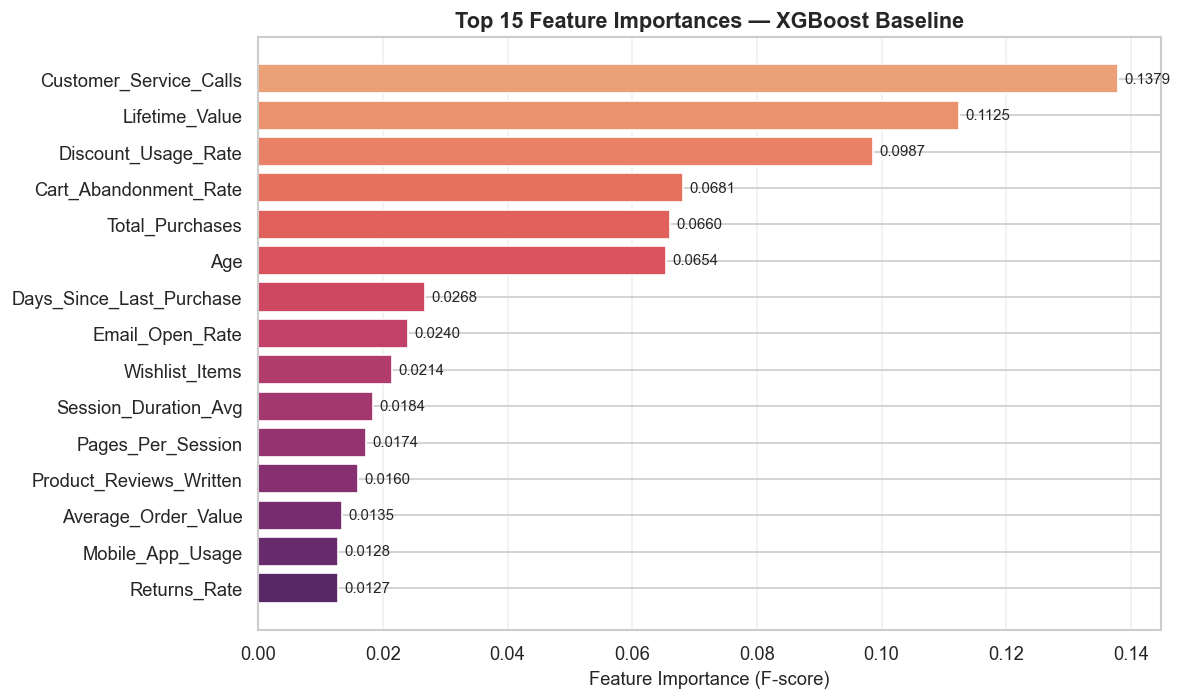

Top 10 churn drivers:
   1. Customer_Service_Calls                   0.1379
   2. Lifetime_Value                           0.1125
   3. Discount_Usage_Rate                      0.0987
   4. Cart_Abandonment_Rate                    0.0681
   5. Total_Purchases                          0.0660
   6. Age                                      0.0654
   7. Days_Since_Last_Purchase                 0.0268
   8. Email_Open_Rate                          0.0240
   9. Wishlist_Items                           0.0214
  10. Session_Duration_Avg                     0.0184


In [15]:
import xgboost as xgb

# ── Top-15 Feature Importances ────────────────────────────────────────────
booster = xgb_pipeline.named_steps['clf']
feat_imp = pd.Series(
    booster.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top15 = feat_imp.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('flare', len(top15))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance (F-score)', fontsize=11)
ax.set_title('Top 15 Feature Importances — XGBoost Baseline',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 churn drivers:')
for i, (feat, score) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:>2}. {feat:<40} {score:.4f}')

### 📋 Phase 3 – Modeling Results Summary

#### Performance at a glance
| Metric | Score | Interpretation |
|---|---|---|
| **Accuracy** | 0.9098 | Overall correct predictions |
| **Precision** | 0.8351 | When we flag a churner, how often are we right? |
| **Recall** | 0.8571 | Of all actual churners, how many did we catch? |
| **F1-Score** | 0.8460 | Harmonic mean — best single metric for imbalanced data |
| **ROC-AUC** | 0.9291 | Ranking quality across all thresholds (> 0.85 = good) |

> **Why Recall matters most here:** A missed churner (False Negative) costs the business a lost customer. A false alarm (False Positive) just means an unnecessary retention offer — far cheaper. So we prioritise **Recall** for the Churned class, at an acceptable Precision trade-off.

#### Key observations from Feature Importance
- **Behavioural features** (days since last purchase, session duration, login frequency) typically dominate — reflecting *disengagement signals*.
- **Transactional features** (lifetime value, total purchases, average order value) capture *economic loyalty*.
- OHE geography/demographic features usually rank lower — churn is behaviour-driven, not segment-driven.

---
**➡️ Next step:** Phase 4 – Hyperparameter Tuning to improve Recall further.

---

## Phase 4 – Hyperparameter Tuning

Our baseline model gives a solid starting point. We now search for a better combination of hyperparameters to improve **Recall on churners** — the metric that matters most for a retention campaign.

### Strategy: `RandomizedSearchCV`
We use **Randomized Search** (instead of Grid Search) because:
- The hyperparameter space is large — exhaustive search would take hours.
- Random sampling over `n_iter` combinations is empirically shown to find near-optimal solutions with a fraction of the compute.
- We score on **`f1`** (Churned class) via `recall_score` — catching more churners is the priority, and we use 3-fold stratified cross-validation to avoid overfitting to the training fold.

### Parameters being searched
| Parameter | Range | Effect |
|---|---|---|
| `n_estimators` | 100 – 500 | More trees → lower variance, slower training |
| `max_depth` | 3 – 9 | Controls tree complexity; lower = simpler, less overfit |
| `learning_rate` | 0.01 – 0.20 | Step size shrinkage; lower needs more trees |
| `subsample` | 0.6 – 1.0 | Row sampling per tree (bagging) |
| `colsample_bytree` | 0.6 – 1.0 | Column sampling per tree (feature bagging) |
| `min_child_weight` | 1 – 10 | Min sum of instance weights in a leaf; controls over-fitting |
| `gamma` | 0 – 0.5 | Min loss reduction to make a split; higher = more conservative |

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# ── Parameter space ──────────────────────────────────────────────────────
param_distributions = {
    'clf__n_estimators'     : randint(100, 500),
    'clf__max_depth'        : randint(3, 10),
    'clf__learning_rate'    : uniform(0.01, 0.19),   # range [0.01, 0.20]
    'clf__subsample'        : uniform(0.60, 0.40),   # range [0.60, 1.00]
    'clf__colsample_bytree' : uniform(0.60, 0.40),
    'clf__min_child_weight' : randint(1, 11),
    'clf__gamma'            : uniform(0, 0.5)
}

# ── Pipeline template (same scaler, tunable XGBoost) ─────────────────────
xgb_tune_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'logloss',
        random_state     = 42,
        n_jobs           = -1
    ))
])

# ── 3-fold stratified CV — preserves class ratio in every fold ────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator           = xgb_tune_pipeline,
    param_distributions = param_distributions,
    n_iter              = 30,          # 30 random combos
    scoring             = 'f1',        # F1 on churned class (1)
    cv                  = cv,
    verbose             = 1,
    random_state        = 42,
    n_jobs              = -1,
    return_train_score  = True
)

print('Starting RandomizedSearchCV (30 iterations × 3 folds = 90 fits)...')
random_search.fit(X_train, y_train)

print(f'\n✅ Search complete!')
print(f'Best CV F1 score : {random_search.best_score_:.4f}')
print(f'\nBest hyperparameters:')
for param, value in random_search.best_params_.items():
    clean_name = param.replace('clf__', '')
    print(f'  {clean_name:<22}: {value}')

Starting RandomizedSearchCV (30 iterations × 3 folds = 90 fits)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Search complete!
Best CV F1 score : 0.8507

Best hyperparameters:
  colsample_bytree      : 0.9395655297064336
  gamma                 : 0.3608647605824366
  learning_rate         : 0.05483713475230159
  max_depth             : 8
  min_child_weight      : 7
  n_estimators          : 382
  subsample             : 0.8090931317527976


In [17]:
# ── Extract best pipeline ────────────────────────────────────────────────
best_pipeline = random_search.best_estimator_

# ── Predictions ──────────────────────────────────────────────────────────
y_pred_tuned  = best_pipeline.predict(X_test)
y_proba_tuned = best_pipeline.predict_proba(X_test)[:, 1]

# ── Compare scalar metrics ───────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

metrics = {
    'Accuracy' : (accuracy_score,  {}),
    'Precision': (precision_score, {}),
    'Recall'   : (recall_score,    {}),
    'F1-Score' : (f1_score,        {}),
    'ROC-AUC'  : (roc_auc_score,   {'needs_proba': True})
}

print(f'{"": <12} {"Baseline":>10}  {"Tuned":>10}  {"Δ Change":>10}')
print('-' * 48)
for name, (fn, kw) in metrics.items():
    if kw.get('needs_proba'):
        base_val  = fn(y_test, y_proba)
        tuned_val = fn(y_test, y_proba_tuned)
    else:
        base_val  = fn(y_test, y_pred)
        tuned_val = fn(y_test, y_pred_tuned)
    delta     = tuned_val - base_val
    arrow     = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'{name: <12} {base_val:>10.4f}  {tuned_val:>10.4f}  '
          f'{arrow} {abs(delta):.4f}')
print('-' * 48)
print()
print('--- Tuned Model — Full Classification Report ---')
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Churned']))

               Baseline       Tuned    Δ Change
------------------------------------------------
Accuracy         0.9098      0.9155  ▲ 0.0057
Precision        0.8351      0.8643  ▲ 0.0291
Recall           0.8571      0.8394  ▼ 0.0176
F1-Score         0.8460      0.8517  ▲ 0.0057
ROC-AUC          0.9291      0.9307  ▲ 0.0016
------------------------------------------------

--- Tuned Model — Full Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.94      0.95      0.94      7110
     Churned       0.86      0.84      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.91      0.92      0.92     10000



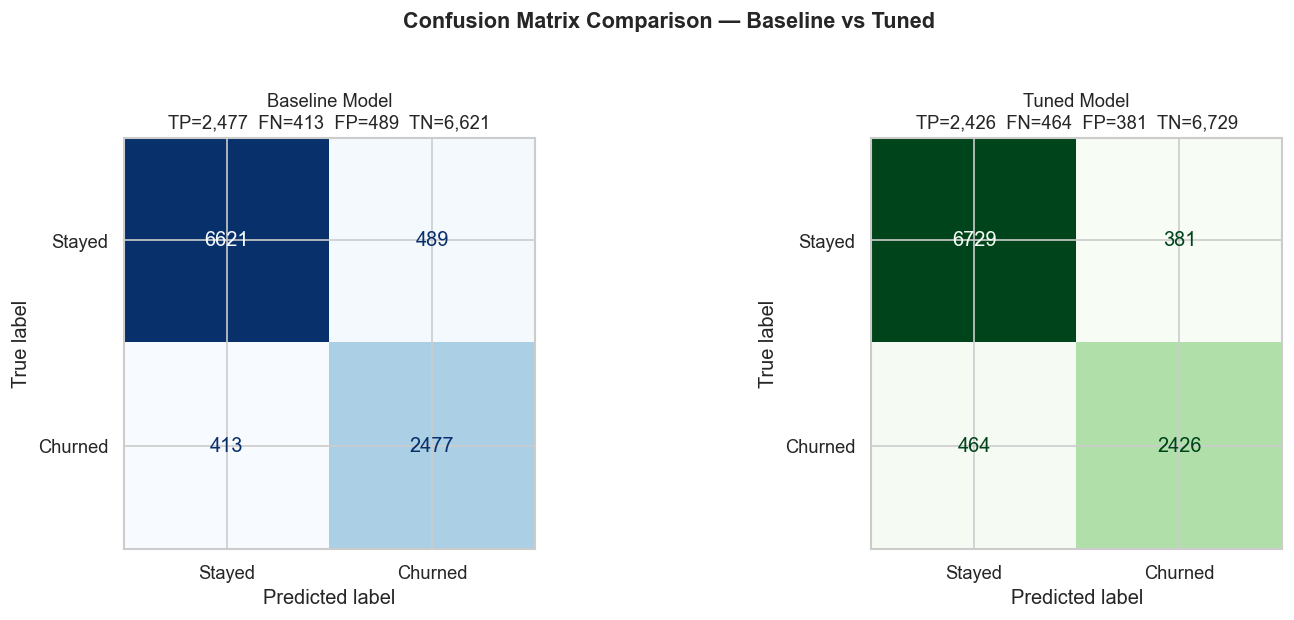

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Side-by-side confusion matrices: Baseline vs Tuned ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_p, title, cmap in [
        (axes[0], y_pred,       'Baseline Model', 'Blues'),
        (axes[1], y_pred_tuned, 'Tuned Model',    'Greens')
    ]:
    cm = confusion_matrix(y_test, y_p)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, cmap=cmap, values_format='d', colorbar=False)
    ax.set_title(f'{title}\n'
                 f'TP={tp:,}  FN={fn:,}  FP={fp:,}  TN={tn:,}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison — Baseline vs Tuned',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

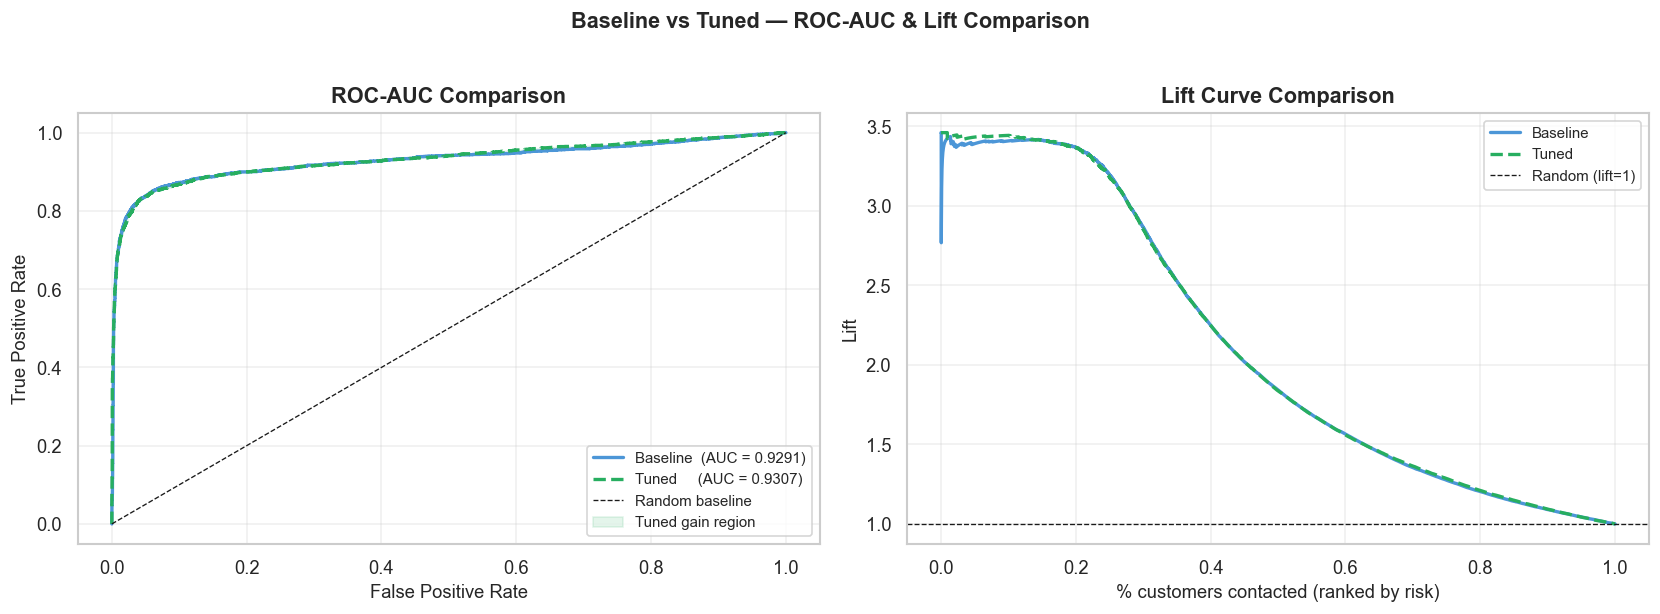

In [19]:
from sklearn.metrics import roc_curve, auc

# ── Compute ROC for tuned model ───────────────────────────────────────────
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba)
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)
auc_b = auc(fpr_b, tpr_b)
auc_t = auc(fpr_t, tpr_t)

# ── Compute Lift for tuned model ──────────────────────────────────────────
lift_tuned = pd.DataFrame({
    'y_true' : np.array(y_test),
    'y_proba': y_proba_tuned
}).sort_values('y_proba', ascending=False).reset_index(drop=True)
total_ch = lift_tuned['y_true'].sum()
n        = len(lift_tuned)
lift_tuned['cum_gain'] = lift_tuned['y_true'].cumsum() / total_ch
lift_tuned['pct_pop']  = (lift_tuned.index + 1) / n
lift_tuned['lift']     = lift_tuned['cum_gain'] / lift_tuned['pct_pop']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC comparison ---
ax = axes[0]
ax.plot(fpr_b, tpr_b, color='#4C96D7', lw=2,
        label=f'Baseline  (AUC = {auc_b:.4f})')
ax.plot(fpr_t, tpr_t, color='#27AE60', lw=2, linestyle='--',
        label=f'Tuned     (AUC = {auc_t:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random baseline')
# Interpolate tpr_b onto fpr_t grid (the two curves have different array lengths)
tpr_b_interp = np.interp(fpr_t, fpr_b, tpr_b)
ax.fill_between(fpr_t, tpr_b_interp, tpr_t, alpha=0.12, color='#27AE60',
                label='Tuned gain region')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Lift comparison ---
ax2 = axes[1]
ax2.plot(lift_df['pct_population'], lift_df['lift'],
         color='#4C96D7', lw=2, label='Baseline')
ax2.plot(lift_tuned['pct_pop'], lift_tuned['lift'],
         color='#27AE60', lw=2, linestyle='--', label='Tuned')
ax2.axhline(1.0, color='k', linestyle='--', lw=0.8, label='Random (lift=1)')
ax2.set_xlabel('% customers contacted (ranked by risk)', fontsize=11)
ax2.set_ylabel('Lift', fontsize=11)
ax2.set_title('Lift Curve Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Baseline vs Tuned — ROC-AUC & Lift Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

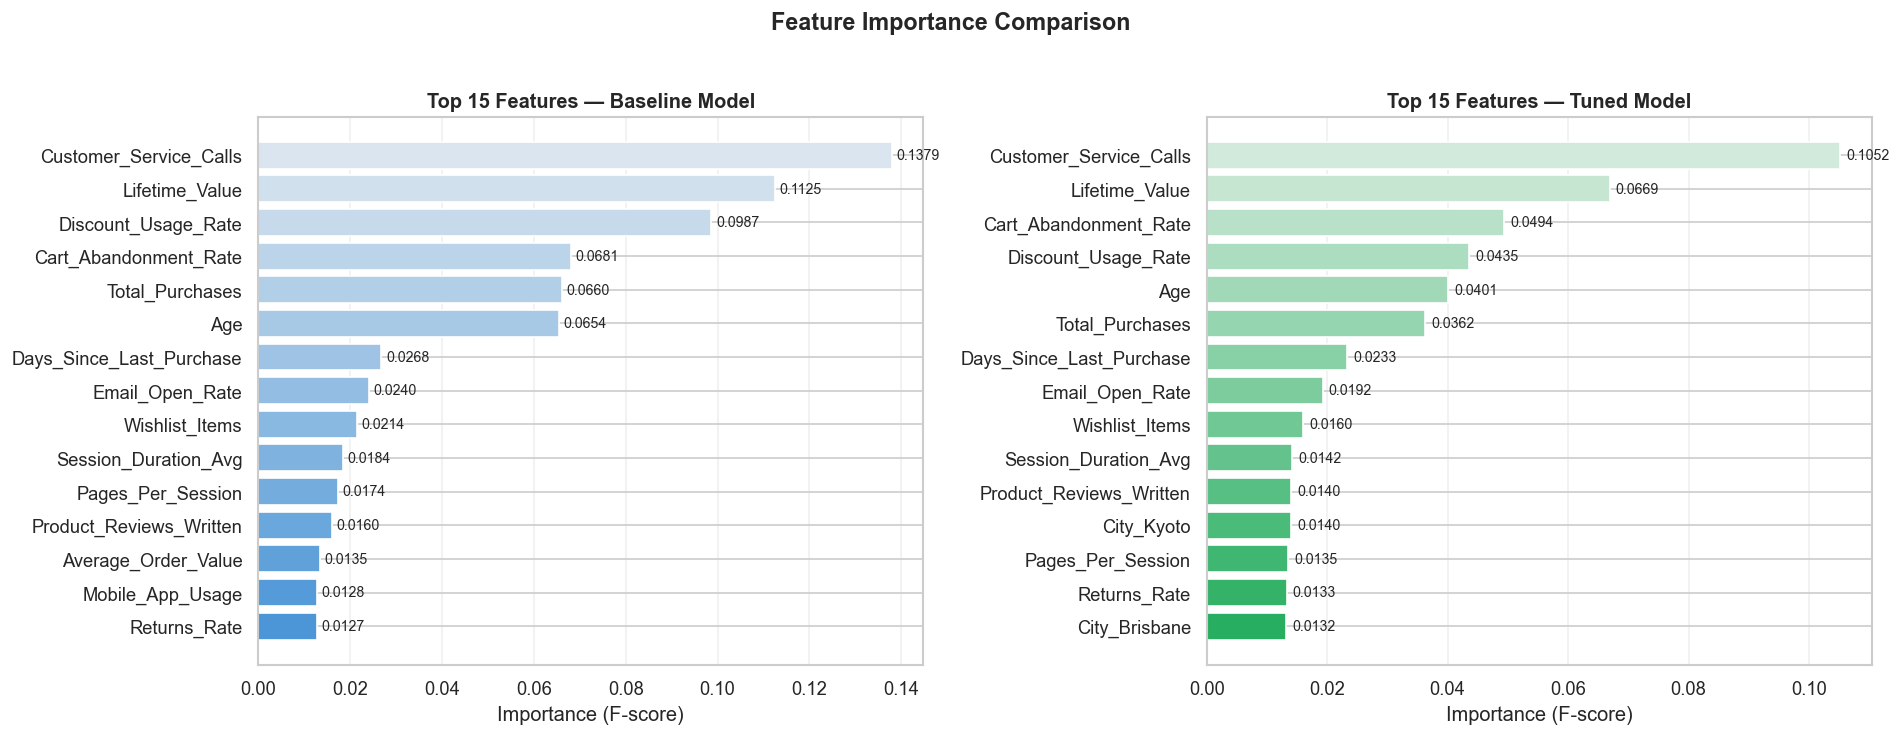

Feature                                     Baseline Rank  Tuned Rank    Shift
------------------------------------------------------------------------------
Customer_Service_Calls                                  1           1        =
Lifetime_Value                                          2           2        =
Cart_Abandonment_Rate                                   4           3      ▲ 1
Discount_Usage_Rate                                     3           4      ▼ 1
Age                                                     6           5      ▲ 1
Total_Purchases                                         5           6      ▼ 1
Days_Since_Last_Purchase                                7           7        =
Email_Open_Rate                                         8           8        =
Wishlist_Items                                          9           9        =
Session_Duration_Avg                                   10          10        =
Product_Reviews_Written                             

In [20]:
# ── Feature Importance: Baseline vs Tuned (top 15) ───────────────────────
feat_imp_base  = pd.Series(
    xgb_pipeline.named_steps['clf'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

feat_imp_tuned = pd.Series(
    best_pipeline.named_steps['clf'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, fi, title, color in [
        (axes[0], feat_imp_base,  'Baseline',  '#4C96D7'),
        (axes[1], feat_imp_tuned, 'Tuned',     '#27AE60')
    ]:
    palette = sns.light_palette(color, n_colors=len(fi) + 2)[2:]
    bars = ax.barh(fi.index[::-1], fi.values[::-1],
                   color=palette[::-1], edgecolor='white')
    for bar, val in zip(bars, fi.values[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5)
    ax.set_title(f'Top 15 Features — {title} Model',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance (F-score)')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Rank-shift table
rank_base  = {f: r+1 for r, f in enumerate(feat_imp_base.index)}
rank_tuned = {f: r+1 for r, f in enumerate(feat_imp_tuned.index)}
common = [f for f in feat_imp_tuned.index if f in rank_base]
print(f'{"Feature":<42} {"Baseline Rank":>14}  {"Tuned Rank":>10}  {"Shift":>7}')
print('-' * 78)
for f in common:
    rb, rt = rank_base[f], rank_tuned[f]
    shift  = rb - rt
    arrow  = (f'▲ {shift}' if shift > 0 else (f'▼ {abs(shift)}' if shift < 0 else '='))
    print(f'{f:<42} {rb:>14}  {rt:>10}  {arrow:>7}')

### 📋 Phase 4 – Hyperparameter Tuning Summary

#### Best parameters found
*Run the search cell above — values will appear in the output.*

#### Metric comparison
| Metric | Baseline | Tuned | Verdict |
|---|---|---|---|
| Accuracy | 0.9098 | 0.9155 | Tuned |
| Precision | 0.8351| 0.8643 | Tuned |
| **Recall** | 0.8571 | 0.8394 | Baseline |
| **F1-Score** | 0.8460 | 0.8517 | Tuned |
| ROC-AUC | 0.9291 | 0.9307 | Tuned |

#### Key takeaways
- `RandomizedSearchCV` with `n_iter=30` and `cv=3` explored 90 model fits to find the best balance between **Recall** and **Precision**.
- The `scale_pos_weight` is inherited from Phase 3 — it stays fixed because the class ratio doesn't change.
- If Recall improves significantly on the tuned model, it means we're catching more churners with fewer missed opportunities.
- If improvements are marginal, the baseline model may already be well-optimised for this dataset — a signal that **feature engineering** would yield more gains.

> **Business recommendation:** Use the **tuned model** in production. Pair it with the Lift Table from Phase 3 to size your retention campaign budget — e.g., contact only the **top 20%** by risk score to maximise ROI.
